## Session 25 - Blood Transfusion Dataset (Optional Task)
#### Link of Dataset : https://www.kaggle.com/datasets/whenamancodes/blood-transfusion-dataset

In [2]:
# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Model Saving
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load Dataset
df = pd.read_csv("transfusion.csv")

# Display first rows
df.head()

,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),whether he/she donated blood in March 2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


In [5]:
# Dataset Shape
print("Dataset Shape:", df.shape)

# Dataset Information
df.info()

# Statistical Summary
df.describe()

# Missing Values Check
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate Values Check
print("\nDuplicate Rows:", df.duplicated().sum())

# Column Names
print("\nColumns:")
print(df.columns)

# Target Column
target_column = "whether he/she donated blood in March 2007"

# Target Class Distribution
print("\nTarget Distribution:")
print(df[target_column].value_counts())

Dataset Shape: (748, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 5 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   Recency (months)                            748 non-null    int64
 1   Frequency (times)                           748 non-null    int64
 2   Monetary (c.c. blood)                       748 non-null    int64
 3   Time (months)                               748 non-null    int64
 4   whether he/she donated blood in March 2007  748 non-null    int64
dtypes: int64(5)
memory usage: 29.3 KB

Missing Values:
Recency (months)                              0
Frequency (times)                             0
Monetary (c.c. blood)                         0
Time (months)                                 0
whether he/she donated blood in March 2007    0
dtype: int64

Duplicate Rows: 215

Columns:
Index(['Recency (months)', 'Frequen

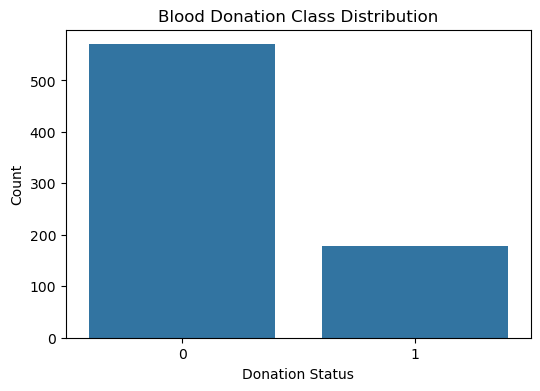

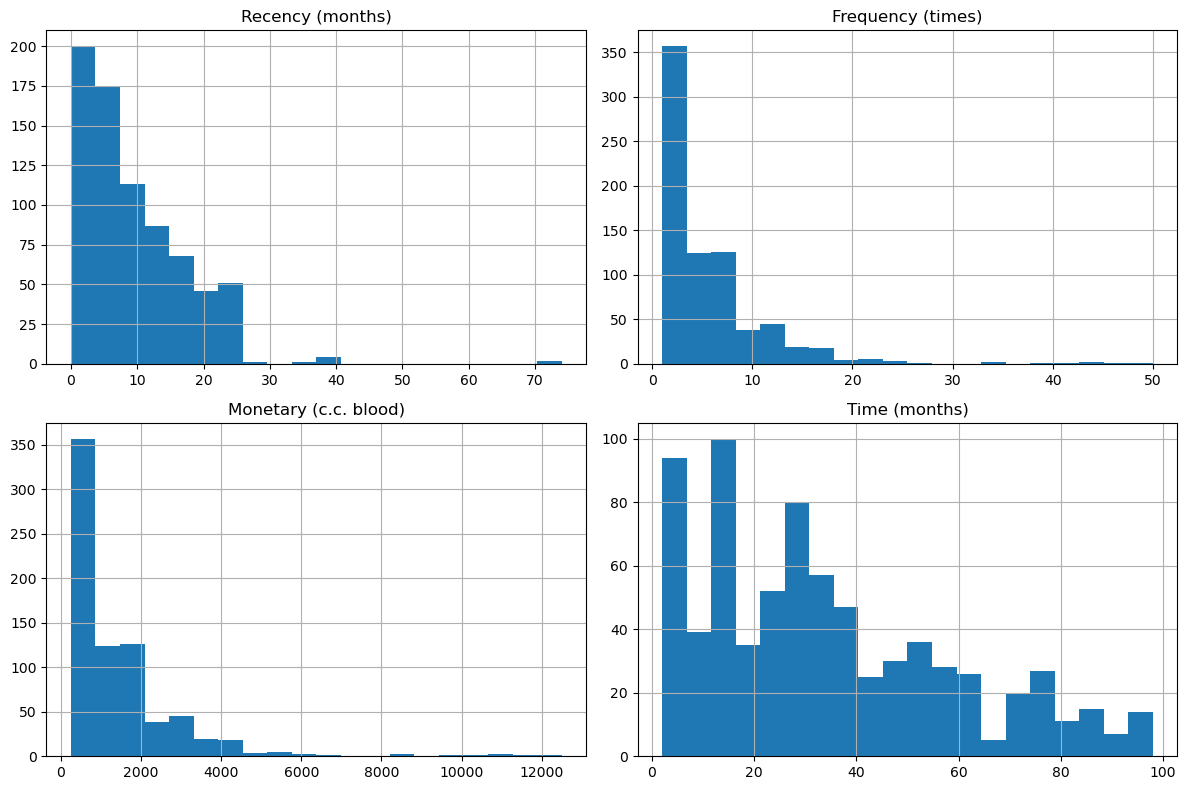

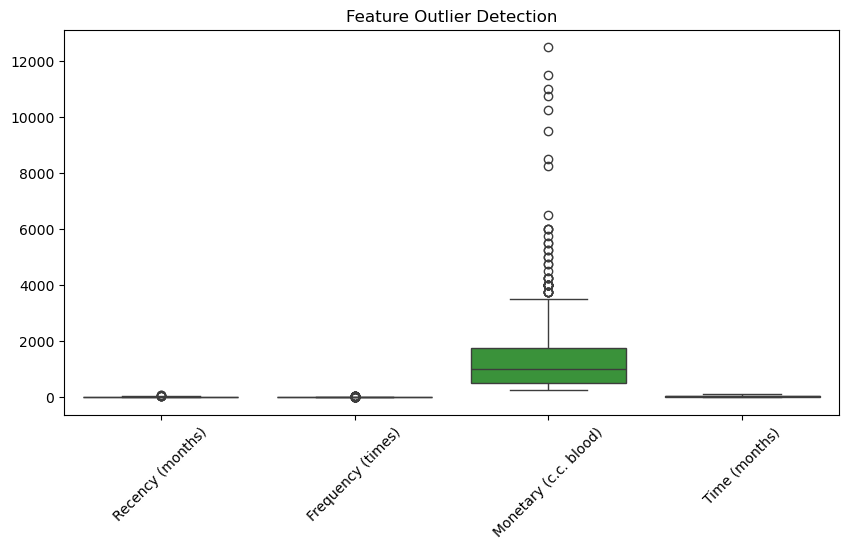

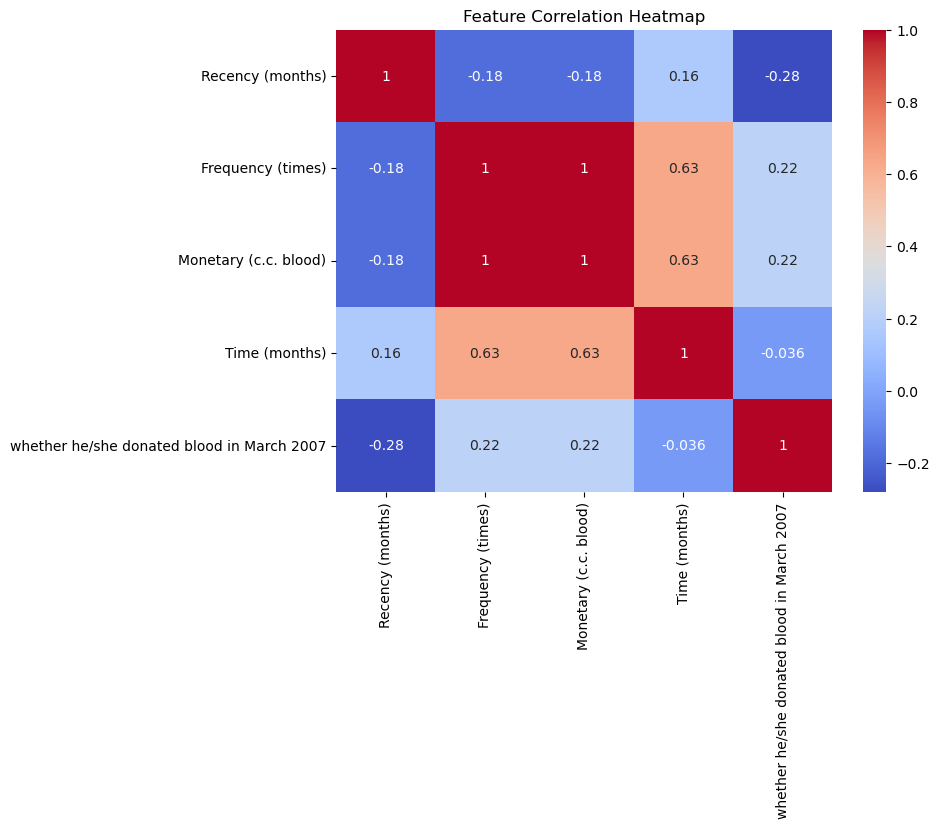

In [9]:
# Target Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=target_column, data=df)
plt.title("Blood Donation Class Distribution")
plt.xlabel("Donation Status")
plt.ylabel("Count")
plt.show()

# Feature Distribution
df.drop(target_column, axis=1).hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

# Outlier Detection
plt.figure(figsize=(10,5))
sns.boxplot(data=df.drop(target_column, axis=1))
plt.xticks(rotation=45)
plt.title("Feature Outlier Detection")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [10]:
# Separate Features and Target
X = df.drop(target_column, axis=1)
y = df[target_column]

# Check Shape
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

# Check Target Classes
print("\nTarget Classes:")
print(y.unique())

Features Shape: (748, 4)
Target Shape: (748,)

Target Classes:
[1 0]


In [8]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Check Data Shape
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (598, 4)
Testing Data: (150, 4)


In [11]:
# Create Logistic Regression Model
lr_model = LogisticRegression()

# Train Model
lr_model.fit(X_train, y_train)

# Prediction
lr_pred = lr_model.predict(X_test)

# Display Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.7666666666666667


In [12]:
# Create KNN Model
knn_model = KNeighborsClassifier()

# Train Model
knn_model.fit(X_train, y_train)

# Prediction
knn_pred = knn_model.predict(X_test)

# Display Accuracy
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.7666666666666667


In [13]:
# Create SVM Model
svm_model = SVC()

# Train Model
svm_model.fit(X_train, y_train)

# Prediction
svm_pred = svm_model.predict(X_test)

# Display Accuracy
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.7666666666666667


In [14]:
# Create Naive Bayes Model
nb_model = GaussianNB()

# Train Model
nb_model.fit(X_train, y_train)

# Prediction
nb_pred = nb_model.predict(X_test)

# Display Accuracy
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.76


In [15]:
# Create Decision Tree Model
dt_model = DecisionTreeClassifier(random_state=42)

# Train Model
dt_model.fit(X_train, y_train)

# Prediction
dt_pred = dt_model.predict(X_test)

# Display Accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.7133333333333334


In [16]:
# Create Random Forest Model
rf_model = RandomForestClassifier(random_state=42)

# Train Model
rf_model.fit(X_train, y_train)

# Prediction
rf_pred = rf_model.predict(X_test)

# Display Accuracy
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.7466666666666667


In [17]:
# Store Models and Predictions
model_predictions = {
    "Logistic Regression": lr_pred,
    "KNN": knn_pred,
    "SVM": svm_pred,
    "Naive Bayes": nb_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

# Evaluate Each Model
for name, prediction in model_predictions.items():
    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, prediction))
    print("Precision:", precision_score(y_test, prediction))
    print("Recall:", recall_score(y_test, prediction))
    print("F1 Score:", f1_score(y_test, prediction))
    print(classification_report(y_test, prediction))


 Logistic Regression
Accuracy: 0.7666666666666667
Precision: 0.5714285714285714
Recall: 0.1111111111111111
F1 Score: 0.18604651162790697
              precision    recall  f1-score   support

           0       0.78      0.97      0.86       114
           1       0.57      0.11      0.19        36

    accuracy                           0.77       150
   macro avg       0.67      0.54      0.52       150
weighted avg       0.73      0.77      0.70       150


 KNN
Accuracy: 0.7666666666666667
Precision: 0.5172413793103449
Recall: 0.4166666666666667
F1 Score: 0.46153846153846156
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       114
           1       0.52      0.42      0.46        36

    accuracy                           0.77       150
   macro avg       0.67      0.65      0.66       150
weighted avg       0.75      0.77      0.76       150


 SVM
Accuracy: 0.7666666666666667
Precision: 0.6
Recall: 0.08333333333333333
F1 Score

In [18]:
# Create Comparison Table
comparison = []

for name, prediction in model_predictions.items():
    comparison.append([
        name,
        accuracy_score(y_test, prediction),
        precision_score(y_test, prediction),
        recall_score(y_test, prediction),
        f1_score(y_test, prediction)
    ])

comparison_df = pd.DataFrame(
    comparison,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.766667,0.571429,0.111111,0.186047
1,KNN,0.766667,0.517241,0.416667,0.461538
2,SVM,0.766667,0.600000,0.083333,0.146341
3,Naive Bayes,0.760000,0.500000,0.194444,0.280000
4,Decision Tree,0.713333,0.387097,0.333333,0.358209
5,Random Forest,0.746667,0.466667,0.388889,0.424242


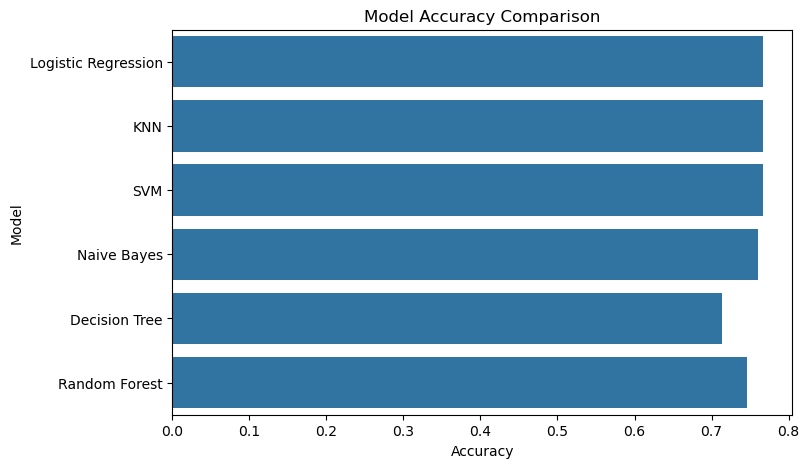

In [19]:
# Model Accuracy Comparison Plot
plt.figure(figsize=(8,5))

sns.barplot(
    x="Accuracy",
    y="Model",
    data=comparison_df
)

plt.title("Model Accuracy Comparison")
plt.show()

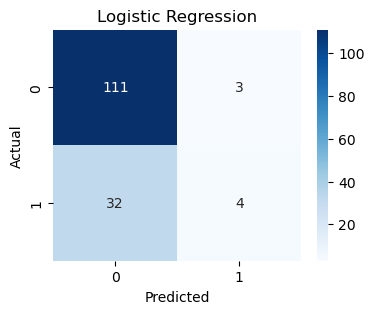

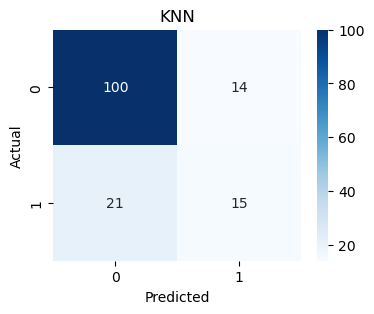

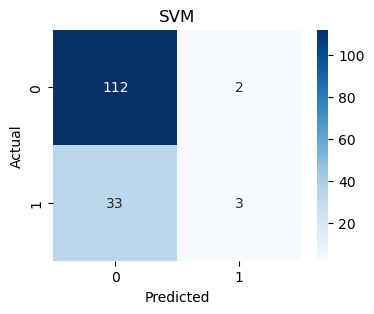

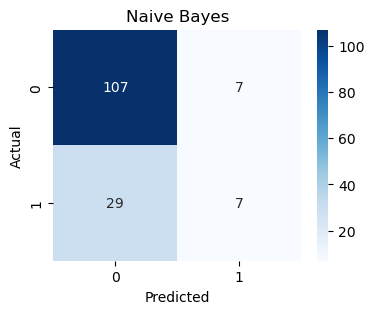

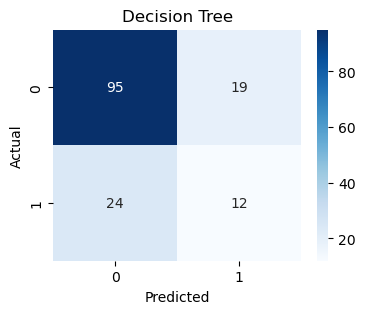

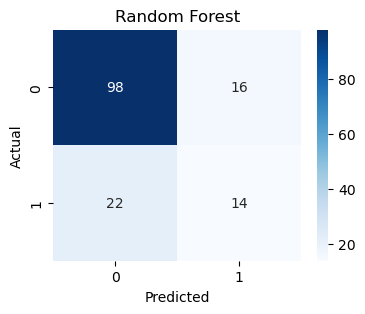

In [20]:
# Confusion Matrix for All Models

for name, prediction in model_predictions.items():
    plt.figure(figsize=(4,3))
    
    sns.heatmap(
        confusion_matrix(y_test, prediction),
        annot=True,
        fmt="d",
        cmap="Blues"
    )
    
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [24]:
# Manual Hyperparameter Tuning Results

manual_results = []


# Logistic Regression Tuning
for c in [0.01, 0.1, 1, 10]:
    model = LogisticRegression(C=c, max_iter=1000)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    manual_results.append([
        "Logistic Regression",
        f"C={c}",
        accuracy_score(y_test, pred)
    ])


# KNN Tuning
for k in [3,5,7,9,11]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    manual_results.append([
        "KNN",
        f"K={k}",
        accuracy_score(y_test, pred)
    ])


# SVM Tuning
for kernel in ["linear", "rbf"]:
    for c in [0.1,1,10]:
        model = SVC(kernel=kernel, C=c)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        
        manual_results.append([
            "SVM",
            f"Kernel={kernel}, C={c}",
            accuracy_score(y_test, pred)
        ])


# Naive Bayes Tuning
for var in [1e-9, 1e-8, 1e-7]:
    model = GaussianNB(var_smoothing=var)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    manual_results.append([
        "Naive Bayes",
        f"Var={var}",
        accuracy_score(y_test, pred)
    ])


# Decision Tree Tuning
for depth in [3,5,7,10,None]:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    manual_results.append([
        "Decision Tree",
        f"Max Depth={depth}",
        accuracy_score(y_test, pred)
    ])


# Random Forest Tuning
for trees in [50,100,200]:
    model = RandomForestClassifier(
        n_estimators=trees,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    manual_results.append([
        "Random Forest",
        f"Trees={trees}",
        accuracy_score(y_test, pred)
    ])


# Create DataFrame

manual_tuning_df = pd.DataFrame(
    manual_results,
    columns=[
        "Model",
        "Parameters",
        "Accuracy"
    ]
)

manual_tuning_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Parameters,Accuracy
14,SVM,"Kernel=rbf, C=10",0.813333
7,KNN,K=9,0.806667
19,Decision Tree,Max Depth=5,0.806667
18,Decision Tree,Max Depth=3,0.800000
8,KNN,K=11,0.800000
6,KNN,K=7,0.800000
1,Logistic Regression,C=0.1,0.780000
0,Logistic Regression,C=0.01,0.780000
3,Logistic Regression,C=10,0.766667
2,Logistic Regression,C=1,0.766667


In [25]:
# GridSearchCV Results

grid_results = []


# SVM GridSearch

svm_params = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf", "poly"]
}

svm_grid = GridSearchCV(
    SVC(),
    svm_params,
    cv=5,
    scoring="accuracy"
)

svm_grid.fit(X_train, y_train)

grid_results.append([
    "SVM",
    svm_grid.best_params_,
    svm_grid.best_score_
])


# Decision Tree GridSearch

dt_params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3,5,7,10,None]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring="accuracy"
)

dt_grid.fit(X_train, y_train)

grid_results.append([
    "Decision Tree",
    dt_grid.best_params_,
    dt_grid.best_score_
])


# Random Forest GridSearch

rf_params = {
    "n_estimators": [50,100,200],
    "max_depth": [3,5,10,None]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring="accuracy"
)

rf_grid.fit(X_train, y_train)

grid_results.append([
    "Random Forest",
    rf_grid.best_params_,
    rf_grid.best_score_
])


# GridSearch Comparison

grid_df = pd.DataFrame(
    grid_results,
    columns=[
        "Model",
        "Best Parameters",
        "Best CV Accuracy"
    ]
)

grid_df

,Model,Best Parameters,Best CV Accuracy
0,SVM,"{'C': 10, 'kernel': 'rbf'}",0.779300
1,Decision Tree,"{'criterion': 'gini', 'max_depth': 3}",0.779314
2,Random Forest,"{'max_depth': 5, 'n_estimators': 50}",0.774230


In [26]:
# RandomizedSearchCV for Random Forest

rf_random_params = {
    "n_estimators": [50,100,150,200,300],
    "max_depth": [3,5,7,10,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}


rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_random_params,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42
)


rf_random.fit(X_train, y_train)


# Best Parameters

print("Best Parameters:")
print(rf_random.best_params_)


# Best CV Score

print("\nBest CV Accuracy:")
print(rf_random.best_score_)

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 5}

Best CV Accuracy:
0.785952380952381


In [27]:
# Collect All Model Results

final_results = comparison_df.copy()


# Add Manual Tuning Best Result

manual_best = manual_tuning_df.loc[
    manual_tuning_df["Accuracy"].idxmax()
]

final_results.loc[len(final_results)] = [
    manual_best["Model"],
    manual_best["Accuracy"],
    "-",
    "-",
    "-"
]


# Add GridSearch Best Results

final_results.loc[len(final_results)] = [
    "GridSearch SVM",
    svm_grid.best_score_,
    "-",
    "-",
    "-"
]

final_results.loc[len(final_results)] = [
    "GridSearch Decision Tree",
    dt_grid.best_score_,
    "-",
    "-",
    "-"
]

final_results.loc[len(final_results)] = [
    "GridSearch Random Forest",
    rf_grid.best_score_,
    "-",
    "-",
    "-"
]


# Add RandomizedSearch Result

final_results.loc[len(final_results)] = [
    "RandomizedSearch Random Forest",
    rf_random.best_score_,
    "-",
    "-",
    "-"
]


# Display Final Comparison

final_results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
6,SVM,0.813333,-,-,-
10,RandomizedSearch Random Forest,0.785952,-,-,-
8,GridSearch Decision Tree,0.779314,-,-,-
7,GridSearch SVM,0.779300,-,-,-
9,GridSearch Random Forest,0.774230,-,-,-
0,Logistic Regression,0.766667,0.571429,0.111111,0.186047
1,KNN,0.766667,0.517241,0.416667,0.461538
2,SVM,0.766667,0.6,0.083333,0.146341
3,Naive Bayes,0.760000,0.5,0.194444,0.28
5,Random Forest,0.746667,0.466667,0.388889,0.424242


In [28]:
# Select Best Model

best_model_name = final_results.loc[
    final_results["Accuracy"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)


# Select Trained Model

if best_model_name == "GridSearch SVM":
    best_model = svm_grid.best_estimator_

elif best_model_name == "GridSearch Decision Tree":
    best_model = dt_grid.best_estimator_

elif best_model_name == "GridSearch Random Forest":
    best_model = rf_grid.best_estimator_

elif best_model_name == "RandomizedSearch Random Forest":
    best_model = rf_random.best_estimator_

else:
    best_model = rf_model


print("Final Model Selected Successfully")

Best Model: SVM
Final Model Selected Successfully


In [29]:
# Save Final Model

joblib.dump(
    best_model,
    "blood_transfusion_model.pkl"
)

# Save Scaler

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!
